# Tutorial on Transformer Feature Visualization

In this notebook, we will explore how to visualize which concepts individual attention heads encode in a Vision Transformer. We follow the same overall workflow as in the CNN feature-visualization tutorial, but adapt it to ViT attention layers and `AttentionHeadConcept`.

## Section 1: Load Dependencies and Set Up Environment

In [12]:
import os

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import zennit.rules as z_rules
from lxt.efficient import monkey_patch, monkey_patch_zennit
from torchvision.models import vision_transformer
from zennit.composites import LayerMapComposite


# Setup environment
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Navigate to repo root
os.chdir("..")
print(f"Working directory: {os.getcwd()}")

# Import CRP modules
from crp.attribution import AttentionAttribution
from crp.concepts import AttentionHeadConcept
from crp.helper import get_layer_names
from crp.visualization import FeatureVisualization

Device: cpu
Working directory: /home/satou/Projects/crp-experimenting


## Section 2: Transformer Feature Visualization Setup

In this section we prepare a ViT-B/16 model, define attention-head concepts, and build a `FeatureVisualization` pipeline for transformer layers.

Important clarification: `composite` and `AttentionAttribution` are from zennit/zennit-crp. LXT is used here only to patch transformer attention operations so that relevance propagation through attention works reliably in this setup.

**TODO:** replace this patch-based step with a pure zennit-crp attention setup when available.

In [13]:
# apply LXT monkey patch – attention-aware relevance propagation
monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

# Create a ViT-B/16 model (pretrained weights not required for this test)
try:
    weights = vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    transformer_model = vision_transformer.vit_b_16(weights=weights).to(device)
    transformer_model.eval()
    print("✓ ViT-B/16 model created successfully")

except Exception as e:
    print(f"✗ Error creating ViT-B/16: {type(e).__name__}: {e}")
    import traceback

    traceback.print_exc()

Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward
✓ ViT-B/16 model created successfully


In [ ]:
# Define zennit composite rules (used by zennit-crp attribution)
# Attention behavior itself is enabled by the LXT model patch above
composite = LayerMapComposite(
    [
        (
            nn.Conv2d, z_rules.Gamma(0.25),
        ),  # value suggested by LXT paper (the first – conv layer – should have a higher gamma)
        (nn.Linear, z_rules.Gamma(0.1)),
    ]
)

# Use AttentionAttribution for transformer models
attribution = AttentionAttribution(transformer_model)

Here we configure a zennit `composite` and initialize `AttentionAttribution` from zennit-crp. The LXT patch is only used to adapt ViT attention internals; attribution logic and feature-visualization flow remain in zennit-crp.

In [ ]:
ahc = AttentionHeadConcept()
layer_names = get_layer_names(transformer_model, [nn.MultiheadAttention])
layer_map = {name: ahc for _, name in enumerate(layer_names)}
print(f"✓ Layer map created with {len(layer_map)} layers")

# separate normalization from resizing for plotting purposes later
transform = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
preprocessing = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

data_path = "ImageNet_data"
# 1. Load the full dataset
imagenet_full = torchvision.datasets.ImageNet(
    data_path, transform=transform, split="val"
)

✓ Layer map created with 12 layers


Here we map each `nn.MultiheadAttention` layer to `AttentionHeadConcept`, then prepare ImageNet preprocessing and a working subset. The dataset labels are later used automatically as class targets during `fv.run(...)`.

In [ ]:
fv_path = "VIT_B16_ImageNet"


def vit_heatmap_modifier(data, on_device=None):
    heatmap = data.grad.detach()
    heatmap = heatmap.to(on_device) if on_device else heatmap
    return torch.sum(heatmap, dim=1)


attribution.heatmap_modifier = vit_heatmap_modifier

fv = FeatureVisualization(
    attribution, imagenet_full, layer_map, preprocess_fn=preprocessing, path=fv_path
)

Finally, we create the `FeatureVisualization` object and override the heatmap aggregation to sum relevance over channels. This keeps output compatible with image-style visualization.

Running the indexing step below computes relevance/activation statistics for the selected subset and **can take a while (often tens of minutes, depending on hardware)**.

In [ ]:
saved_files = fv.run(None, 0, len(imagenet_full), 32, 100)

Running Analysis...


100%|██████████| 132/132 [31:55<00:00, 14.51s/it]


100%|██████████| 1008/1008 [00:00<00:00, 1880.58it/s]


## Section 3: Visualizing the most important concepts with `get_max_reference`

After the feature-visualization index is computed, we can inspect which input samples are most representative for selected attention-head concepts in a given layer. The method `get_max_reference` loads the stored image whit the maximal relevance (the top reference sample) for one the head (the concept ids we ask for).

For transformer models, the concept ids correspond to attention heads. In other words, calling `get_max_reference(..., layer_name="encoder.layers.encoder_layer_11", ...)` asks: *which images in the dataset produced the strongest relevance for these heads in the 11th encoder layer?*

The tuple `r_range=(0, 8)` means that we visualize the top 8 reference samples per concept. If we also pass a `composite`, the method computes conditional heatmaps on those reference samples, so we can see not only *which* images are selected, but also *which parts* of each image support the concept most strongly.

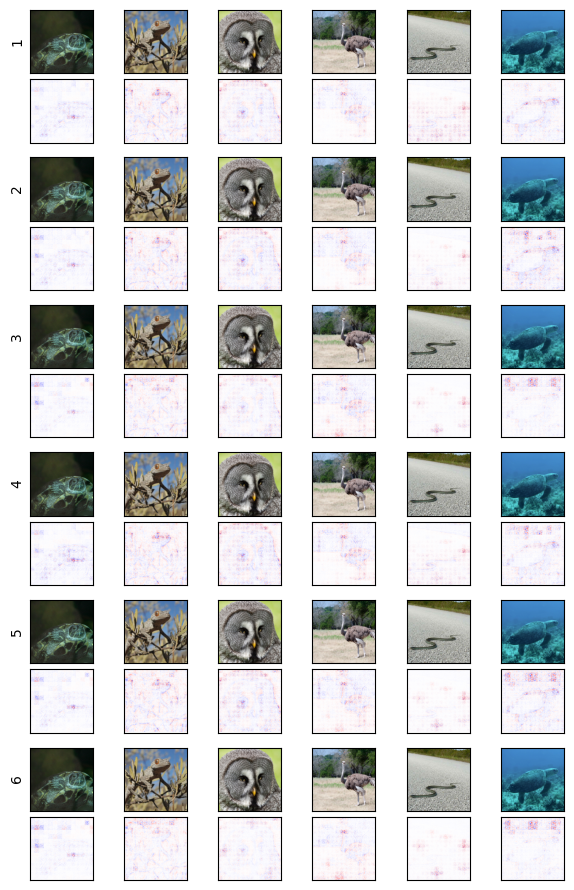

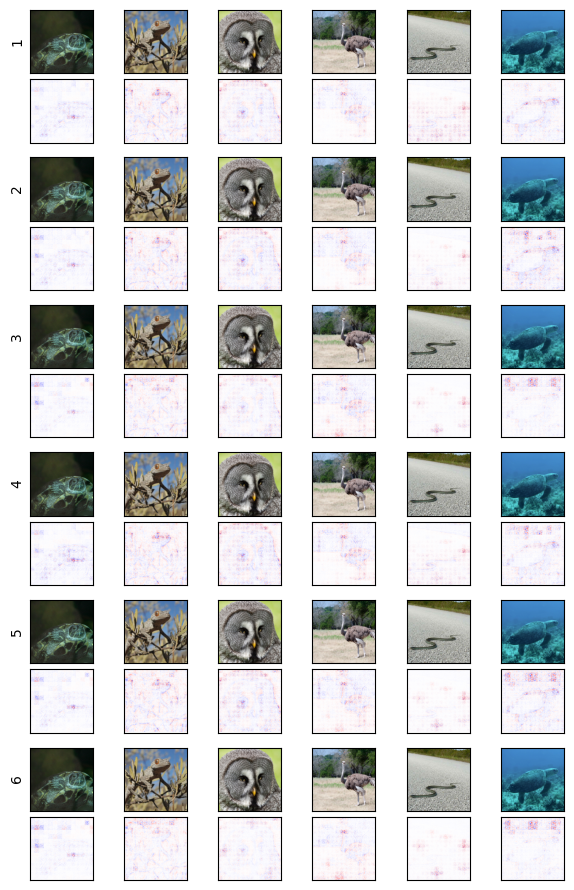

In [17]:
%matplotlib inline
from crp.image import plot_grid


ref_c = fv.get_max_reference(
    concept_ids=[1, 2, 3, 4, 5, 6],
    layer_name="encoder.layers.encoder_layer_11",
    mode="relevance",
    r_range=(0, 6),
    composite=composite,
)

plot_grid(ref_c, figsize=(6, 9), padding=False)

In practice, the heatmaps from `encoder.layers.encoder_layer_11` are often very similar across different heads. A common reason is the strong residual/skip pathway close to the output, which can make head-specific differences less visible in the final block.

Because of that, it is usually more informative to inspect slightly lower but still high-level layers (for example `encoder.layers.encoder_layer_10`) where semantic structure is still strong, yet head-specific patterns are often easier to distinguish.

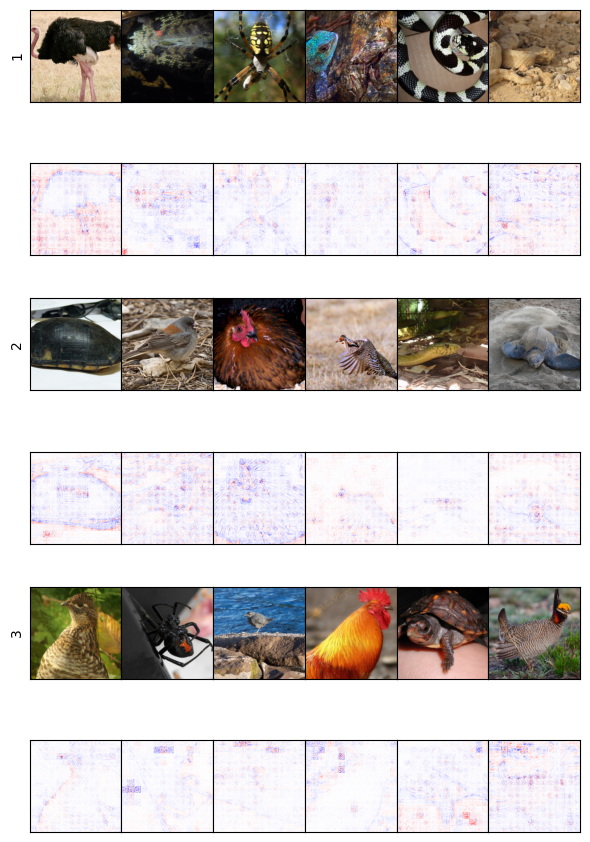

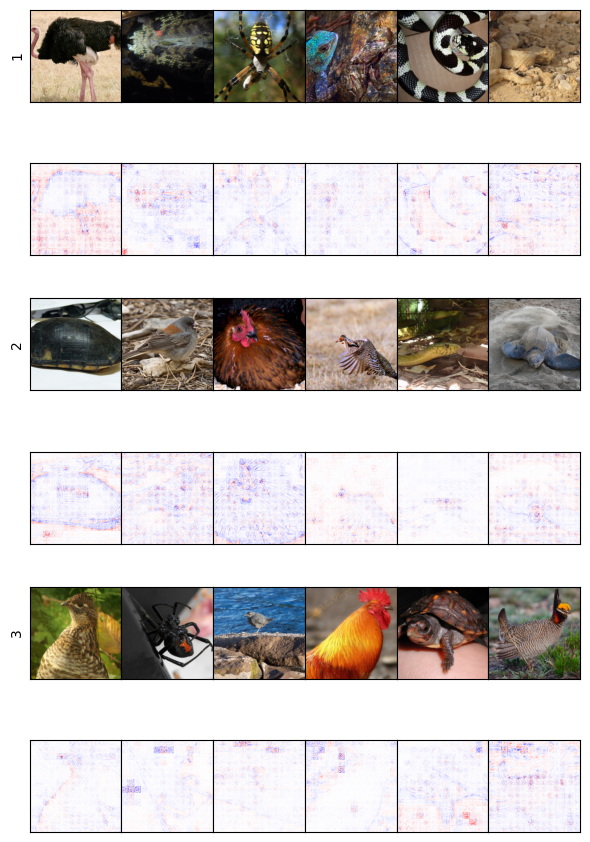

In [ ]:
%matplotlib inline
from crp.image import plot_grid


ref_c = fv.get_max_reference(
    concept_ids=[
        1,
        2,
        3,
        4,
        5,
        6
    ],
    layer_name="encoder.layers.encoder_layer_10",
    mode="relevance",
    r_range=(0, 6),
    composite=composite,
)

plot_grid(ref_c, figsize=(6, 9), padding=False)

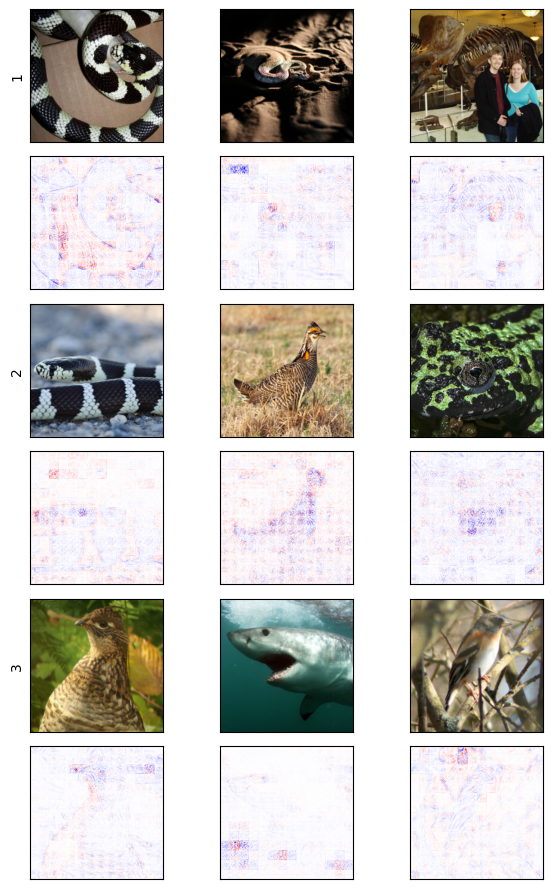

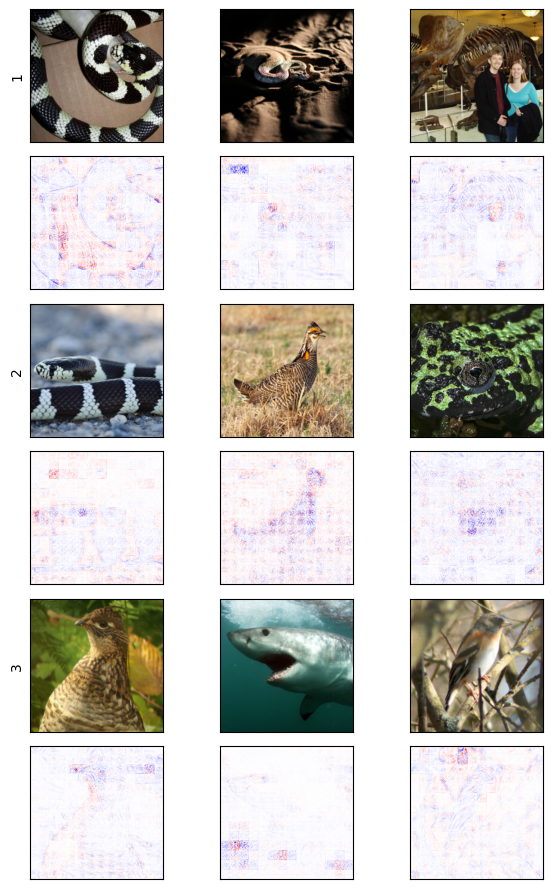

In [ ]:
%matplotlib inline
from crp.image import plot_grid


ref_c = fv.get_max_reference(
    concept_ids=[
        1,
        2,
        3,
    ],
    layer_name="encoder.layers.encoder_layer_9",
    mode="relevance",
    r_range=(0, 6),
    composite=composite,
)

plot_grid(ref_c, figsize=(6, 9), padding=False)

In [9]:
heat_data = np.load(
    "VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11_data.npy"
)
display(heat_data.shape)
heat_rel = np.load(
    "VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11_rel.npy"
)
display(heat_rel.shape)
heat_rf = np.load(
    "VIT_B16_ImageNet/RelMax_sum_normed/encoder.layers.encoder_layer_11_rf.npy"
)
display(heat_rf.shape)

(4200, 197)

(4200, 197)

(4200, 197)